In [42]:

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [54]:
# Формат данных: {ID_работы: {'duration': длительность, 'preds': [предшественники]}}
project_data = {
    1:  {'duration': 4, 'preds': []},
    2:  {'duration': 5, 'preds': [1]},
    3:  {'duration': 3, 'preds': [1]},
    4:  {'duration': 4, 'preds': [2]},
    5:  {'duration': 6, 'preds':[3]},
    6:  {'duration': 3, 'preds': [3]},
    7:  {'duration': 7, 'preds': [3]},
    8:  {'duration': 4, 'preds': [4, 5]},
    9:  {'duration': 5, 'preds':[4, 5]},
    10: {'duration': 5, 'preds': [6]},
    11: {'duration': 3, 'preds': [6]},
    12: {'duration': 7, 'preds': [7, 8, 10]},
    13: {'duration': 6, 'preds':[7, 8, 10]},
    14: {'duration': 4, 'preds':[9, 12]},
    15: {'duration': 5, 'preds': [9, 12]},
    16: {'duration': 0, 'preds': [11, 13, 14, 15]} # ФИКТИВНЫЙ КОНЦЕВОЙ УЗЕЛ

}

print(f"Загружено работ: {len(project_data)}")

Загружено работ: 16


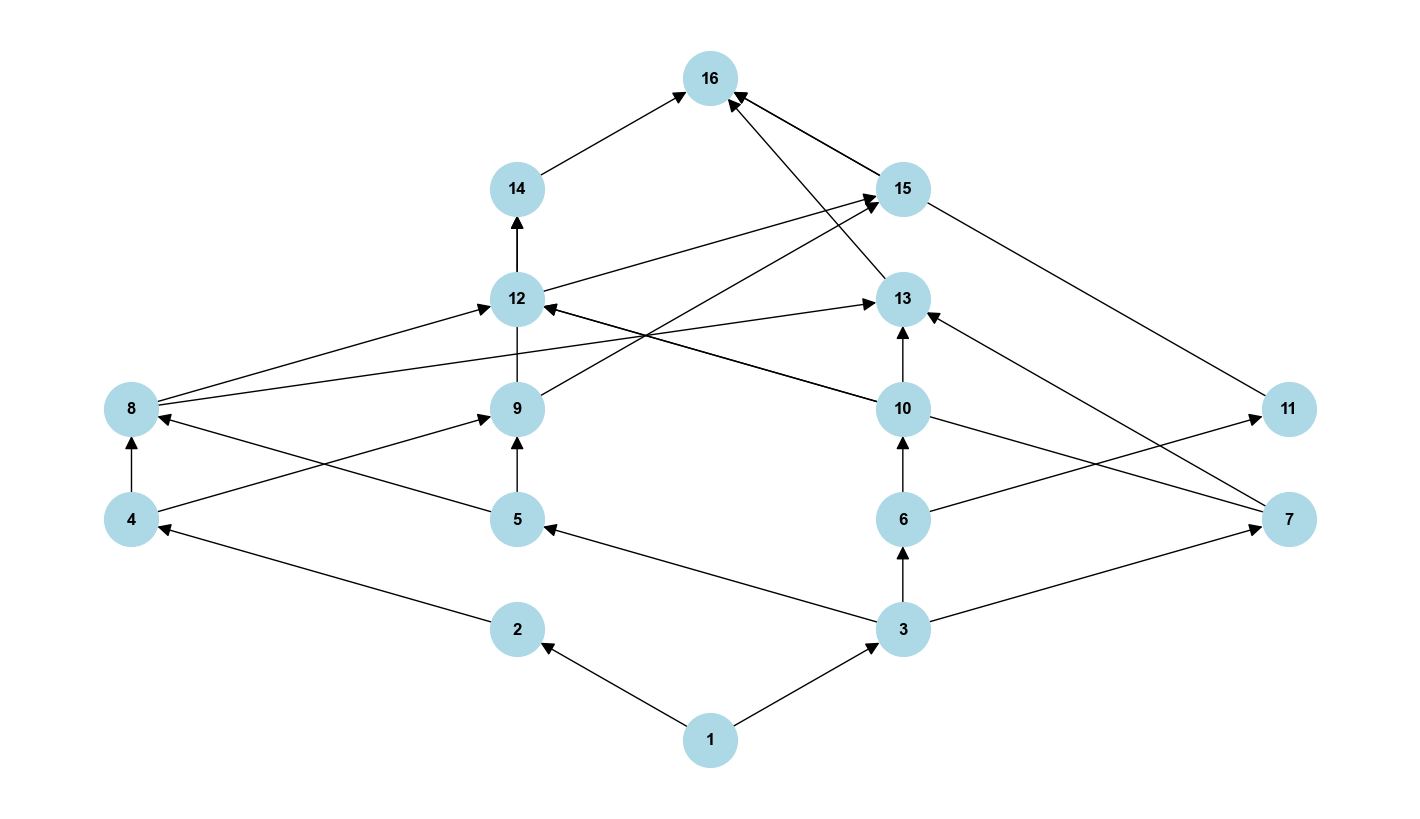

In [55]:
def build_project_graph(data: Dict[int, Dict]) -> nx.DiGraph:
    """Создает NetworkX направленный граф из словаря задач."""
    G = nx.DiGraph()
    for task_id, info in data.items():
        G.add_node(task_id, duration=info['duration'])
        for pred in info['preds']:
            G.add_edge(pred, task_id)
    return G

G = build_project_graph(project_data)

assert nx.is_directed_acyclic_graph(G), "Ошибка: Граф содержит циклы!"

layers = {}
for node in nx.topological_sort(G):
    preds = list(G.predecessors(node))
    if not preds:
        layers[node] = 0
    else:
        layers[node] = max(layers[p] for p in preds) + 1
        
nx.set_node_attributes(G, layers, 'layer')

pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal')
plt.figure(figsize=(14, 8))
nx.draw(G, pos, with_labels=True, node_size=1500, node_color='lightblue', 
        font_size=12, font_weight='bold', arrows=True, arrowsize=20)
plt.show()

In [56]:
import pandas as pd


resources_list = [2, 3, 2, 4, 3, 2, 4, 2, 3, 2, 1, 4, 2, 3, 4, 0]

for i, tid in enumerate(project_data.keys()):
    project_data[tid]['resources'] = resources_list[i]

# Формируем иерархический план (Пункт 2)
plan_data =[]
for task_id, info in project_data.items():
    preds = ", ".join(map(str, info['preds'])) if info['preds'] else "-"
    plan_data.append({
        "Номер работы": task_id,
        "Предшественники": preds,
        "Ресурсы, чел.-дней": info['resources'],
        "Длительность, дней": info['duration']
    })

df_plan = pd.DataFrame(plan_data)

print("ПУНКТ 2: Иерархический план проекта")
display(df_plan)

ПУНКТ 2: Иерархический план проекта


,Номер работы,Предшественники,"Ресурсы, чел.-дней","Длительность, дней"
0,1,-,2,4
1,2,1,3,5
2,3,1,2,3
3,4,2,4,4
4,5,3,3,6
5,6,3,2,3
6,7,3,4,7
7,8,"4, 5",2,4
8,9,"4, 5",3,5
9,10,6,2,5


Минимальный срок реализации проекта (Критический путь): 29 дней



,duration,ES,EF,LS,LF,Slack,Is_Critical
1,4,0,4,0,4,0,True
2,5,4,9,4,9,0,True
3,3,4,7,4,7,0,True
4,4,9,13,9,13,0,True
5,6,7,13,7,13,0,True
6,3,7,10,9,12,2,False
7,7,7,14,10,17,3,False
8,4,13,17,13,17,0,True
9,5,13,18,19,24,6,False
10,5,10,15,12,17,2,False


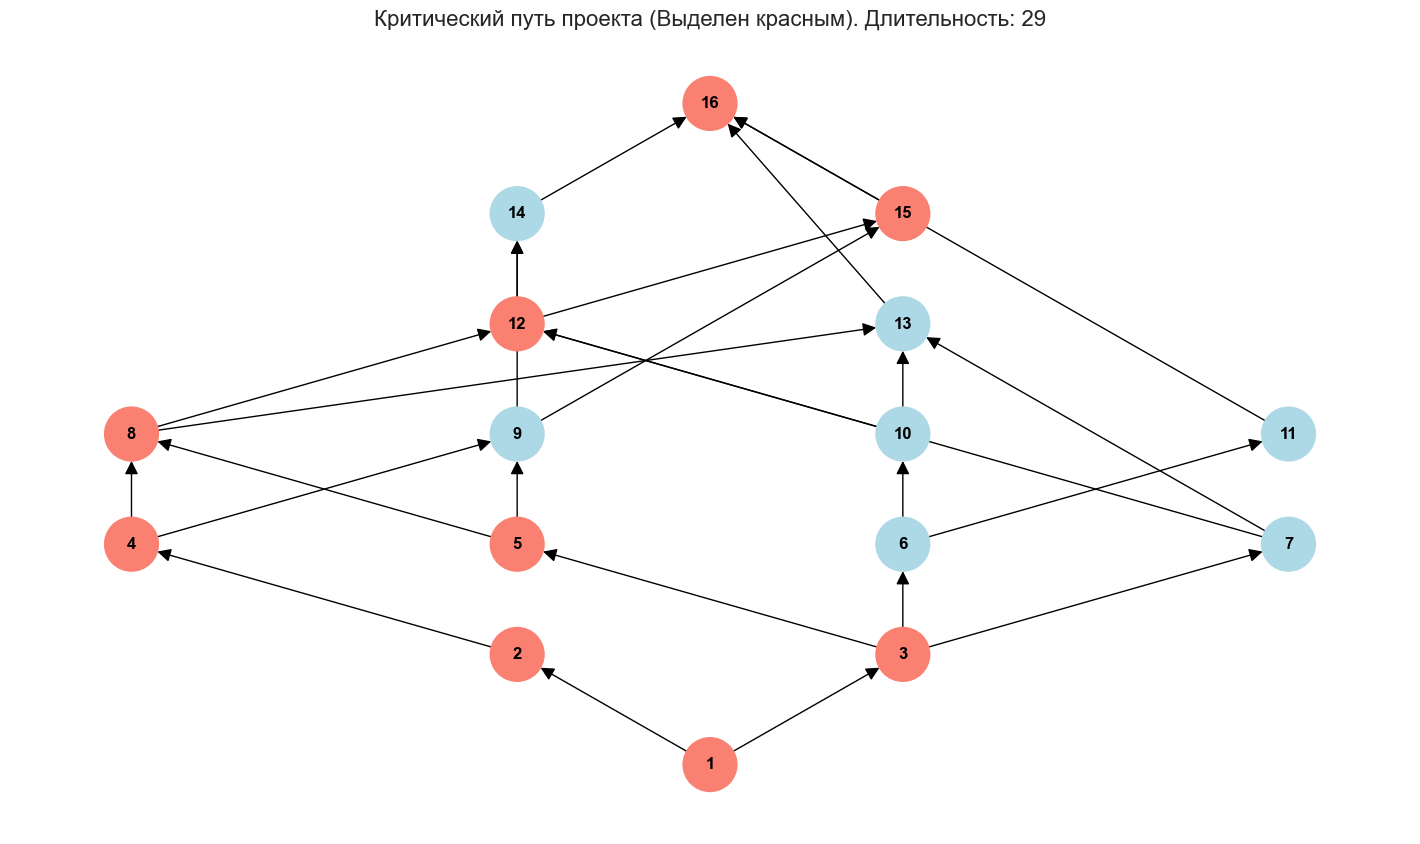

In [57]:
def calculate_cpm(G: nx.DiGraph) -> pd.DataFrame:
    for node in nx.topological_sort(G):
        preds = list(G.predecessors(node))
        es = max([G.nodes[p]['EF'] for p in preds]) if preds else 0
        G.nodes[node]['ES'] = es
        G.nodes[node]['EF'] = es + G.nodes[node]['duration']
        
    project_duration = max([data['EF'] for node, data in G.nodes(data=True)])
    
    for node in reversed(list(nx.topological_sort(G))):
        succs = list(G.successors(node))
        lf = min([G.nodes[s]['LS'] for s in succs]) if succs else project_duration
        G.nodes[node]['LF'] = lf
        G.nodes[node]['LS'] = lf - G.nodes[node]['duration']
        
        # Резерв времени (Slack)
        G.nodes[node]['Slack'] = G.nodes[node]['LS'] - G.nodes[node]['ES']
        G.nodes[node]['Is_Critical'] = G.nodes[node]['Slack'] == 0

    df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
    return df, project_duration

cpm_df, total_time = calculate_cpm(G)

print(f"Минимальный срок реализации проекта (Критический путь): {total_time} дней\n")
display(cpm_df.sort_index()[['duration', 'ES', 'EF', 'LS', 'LF', 'Slack', 'Is_Critical']])

critical_nodes = [node for node, data in G.nodes(data=True) if data['Is_Critical']]
node_colors = ['salmon' if node in critical_nodes else 'lightblue' for node in G.nodes()]

plt.figure(figsize=(14, 8))
nx.draw(G, pos, with_labels=True, node_size=1500, node_color=node_colors, 
        font_size=12, font_weight='bold', arrows=True, arrowsize=20)
plt.title(f"Критический путь проекта (Выделен красным). Длительность: {total_time}", fontsize=16)
plt.show()

In [58]:
from scipy.optimize import minimize
import numpy as np
import networkx as nx

# 1. Поиск всех полных путей от старта до финиша
G_paths = nx.DiGraph()
G_paths.add_node('Start')
G_paths.add_node('End')

for task_id, info in project_data.items():
    G_paths.add_node(task_id)
    if not info['preds']:
        G_paths.add_edge('Start', task_id)
    else:
        for p in info['preds']:
            G_paths.add_edge(p, task_id)

# Соединяем узлы без последователей с фиктивным узлом 'End'
out_degrees = [n for n, d in G_paths.out_degree() if d == 0 and n != 'End']
for n in out_degrees:
    G_paths.add_edge(n, 'End')

# Получаем все пути (без фиктивных узлов)
all_paths = list(nx.all_simple_paths(G_paths, 'Start', 'End'))
task_paths = [[n for n in path if n not in ['Start', 'End']] for path in all_paths]

# 2. Подготовка данных для оптимизации
task_ids = list(project_data.keys())
t_initial = np.array([project_data[tid]['duration'] for tid in task_ids])
b_initial = np.array([project_data[tid]['resources'] for tid in task_ids])

# Функция пересчета времени от ресурсов (формула со слайда 8)
def calc_t_opt(b_opt):
    return t_initial * np.exp((b_initial - b_opt) / b_initial)

# Целевая функция: минимизация суммы новых длительностей
def objective(b_opt):
    return np.sum(calc_t_opt(b_opt))

# Ограничение 1: Сумма ресурсов остается неизменной
def resource_constraint(b_opt):
    return np.sum(b_opt) - np.sum(b_initial)

# Ограничение 2: Равенство всех полных путей
def path_constraints(b_opt):
    t_opt = calc_t_opt(b_opt)
    t_opt_dict = {tid: t_opt[i] for i, tid in enumerate(task_ids)}
    
    path_times = [sum(t_opt_dict[node] for node in path) for path in task_paths]
    
    # Все пути должны быть равны первому пути (разница = 0)
    constraints = [path_times[0] - pt for pt in path_times[1:]]
    return np.array(constraints)

constraints = [
    {'type': 'eq', 'fun': resource_constraint},
    {'type': 'eq', 'fun': path_constraints}
]

# Границы для ресурсов (чтобы не ушли в минус и не было деления на ноль)
bounds = [(0.1, np.sum(b_initial)) for _ in b_initial]

# Запуск алгоритма (SLSQP - метод последовательного квадратичного программирования)
result = minimize(objective, b_initial, method='SLSQP', bounds=bounds, constraints=constraints)

b_opt = result.x
t_opt = calc_t_opt(b_opt)

# Вывод результатов (Пункт 4)
df_opt = pd.DataFrame({
    'Номер работы': task_ids,
    'Исходные ресурсы': b_initial,
    'Новые ресурсы': np.round(b_opt, 2),
    'Исходное время': t_initial,
    'Новое время': np.round(t_opt, 2)
})

print("ПУНКТ 4: Результат оптимизации ОПГ (Выравнивание ресурсов)")
display(df_opt)

ПУНКТ 4: Результат оптимизации ОПГ (Выравнивание ресурсов)


C:\Users\Rog G16\AppData\Local\Temp\ipykernel_2388\2805623401.py:34: RuntimeWarning: divide by zero encountered in divide
  return t_initial * np.exp((b_initial - b_opt) / b_initial)


,Номер работы,Исходные ресурсы,Новые ресурсы,Исходное время,Новое время
0,1,2,2.0,4,4.0
1,2,3,3.0,5,5.0
2,3,2,2.0,3,3.0
3,4,4,4.0,4,4.0
4,5,3,3.0,6,6.0
5,6,2,2.0,3,3.0
6,7,4,4.0,7,7.0
7,8,2,2.0,4,4.0
8,9,3,3.0,5,5.0
9,10,2,2.0,5,5.0


In [59]:
sum_t_initial = np.sum(t_initial)
sum_t_opt = np.sum(t_opt)
time_saved = sum_t_initial - sum_t_opt

t_opt_dict = {tid: t_opt[i] for i, tid in enumerate(task_ids)}
new_critical_path_len = sum(t_opt_dict[node] for node in task_paths[0])

print("ПУНКТ 5: Практическая интерпретация и экономический эффект\n")

print(f"Исходная сумма времени всех работ: {sum_t_initial:.2f} дней")
print(f"Оптимизированная целевая функция (сумма времени): {sum_t_opt:.2f} дней")
print(f"Общая экономия рабочего времени: {time_saved:.2f} дней\n")
print(f"Исходный критический путь (срок проекта): {total_time:.2f} дней")
print(f"Новый сбалансированный срок проекта: {new_critical_path_len:.2f} дней\n")

print("ИНТЕРПРЕТАЦИЯ:")
print("Алгоритм обобщенного градиентного поиска (ОПГ) успешно выполнил выравнивание сети.")
print("Математическая модель перераспределила ресурсы так, чтобы 'уравнять' все возможные " 
      "пути в графе от старта до финиша. Часть ресурсов была снята с некритических "
      "(коротких) путей и перенаправлена на работы, лежащие на критическом пути.")
print("\nЭКОНОМИЧЕСКИЙ ЭФФЕКТ:")
print(f"Несмотря на то, что общий фонд ресурсов (человеко-дней) остался неизменным "
      f"({np.sum(b_initial)} ед.), грамотное перераспределение позволило сжать суммарные "
      f"временные затраты на {time_saved:.2f} дней. Это значит, что простаивающие на "
      "некритических участках ресурсы теперь используются максимально эффективно, "
      "устраняя 'окна' (slack/резерв времени) во всём проекте.")

ПУНКТ 5: Практическая интерпретация и экономический эффект

Исходная сумма времени всех работ: 71.00 дней
Оптимизированная целевая функция (сумма времени): 71.00 дней
Общая экономия рабочего времени: 0.00 дней

Исходный критический путь (срок проекта): 29.00 дней
Новый сбалансированный срок проекта: 28.00 дней

ИНТЕРПРЕТАЦИЯ:
Алгоритм обобщенного градиентного поиска (ОПГ) успешно выполнил выравнивание сети.
Математическая модель перераспределила ресурсы так, чтобы 'уравнять' все возможные пути в графе от старта до финиша. Часть ресурсов была снята с некритических (коротких) путей и перенаправлена на работы, лежащие на критическом пути.

ЭКОНОМИЧЕСКИЙ ЭФФЕКТ:
Несмотря на то, что общий фонд ресурсов (человеко-дней) остался неизменным (41 ед.), грамотное перераспределение позволило сжать суммарные временные затраты на 0.00 дней. Это значит, что простаивающие на некритических участках ресурсы теперь используются максимально эффективно, устраняя 'окна' (slack/резерв времени) во всём проекте